# 16. 방향을 맞히는 데도 데이터가 부족한가

## Overview

06번이 "지금 데이터를 조합해 짜낼 것도 거의 없다, 남은 길은 새 데이터뿐이다"로
끝났습니다. 근거는 **기울기 0.153**, 실제 변화의 15% 만 예측한다는 것이었습니다.

**그런데 그 진단은 "몇 % 오를까"에 대한 것입니다.** 12번에서 그 목표를 버렸고,
지금은 "오를까 내릴까"를 묻습니다. 같은 데이터로 척도만 바꿔서 62.8% 가 나왔고
확신하는 날만 고르면 72.1% 입니다.

그러면 다시 물어야 합니다: **방향을 맞히는 데도 출하량·기상이 필요한가.**

## 왜 지금 이걸 묻나

06번이 꼽은 새 데이터 1순위(관세청 수입량)는 07번에서 붙여보고 탈락했습니다.
남은 후보는 연 단위이거나(KOSIS 재배면적) 공개 API 존재 여부부터 조사해야
합니다(저장 물량). **비용이 큽니다.**

그 전에 **이미 가진 데이터가 방향 예측에 값을 하는지**부터 재는 게 순서입니다.
값을 못 하면 같은 종류를 더 모아도 소용없습니다.

## 대조가 선명한 이유

19품목 중 **6품목에만** 출하량·기상이 붙어 있습니다.

| 품목 | 출하량 | 기상 |
|---|---|---|
| 감자·배추·생강·미나리·파·양파 | 99% 채움 | 100% 채움 |
| 나머지 13품목 | 0% | 0% |

그래서 **6품목 안에서** 그 피처를 뺐다 넣었다 하면 됩니다. 품목을 바꿔 비교하면
품목 자체의 차이와 섞이지만, 같은 품목에서 피처만 갈면 그게 안 섞입니다.

## 목차

1. 데이터 상태
2. 가설
3. 피처 묶음 정의
4. 노이즈 플로어 재기
5. Ablation 결과
6. 결론

> ## ⚠️ 정정 주의 (21번)
>
> **이 노트북의 결론은 절반만 맞습니다.**
>
> 여기서는 **전체 적중률 하나로만** 판정해 "출하량은 방향 예측에 값을 하지
> 않는다"고 결론냈습니다. 21번에서 **커버리지를 맞춰** 다시 재보니, 커버리지
> 30~60% 구간에서는 출하량이 노이즈를 뚜렷이 넘습니다(최대 **+2.97%p**).
>
> | 커버리지 | 출하량 효과 | 노이즈 | 판정 |
> |---|---|---|---|
> | 80% (사실상 전량) | +0.55%p | 0.84 | 이 노트북 결론이 맞음 |
> | 40% | **+2.97%p** | 1.05 | **뒤집힘** |
>
> **정정된 결론**: 출하량은 예측을 더 잘하게 만들지는 않지만, **어느 날을 믿을지
> 고르는 데는 값을 합니다.** 하필 17번에서 채택한 운영 지점(커버리지 32%)이
> 그 구간입니다.
>
> **기상은 정정되지 않습니다.** 21번에서 기상은 다시 재지 않았고, 여기서 전
> 구간 악화로 나온 결과가 그대로 유효합니다.
>
> 그 결과로 "신규 13품목 매핑 백필의 근거가 사라졌다"는 아래 결론도 **출하량에
> 한해 취소**됩니다.

## 1. 데이터 상태

6품목만 남기고 채움률을 확인합니다. 결측이 많으면 "피처가 값을 못 했다"가
아니라 "피처가 비어 있었다"가 되어 판정이 흐려집니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
raw = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
raw["price_date"] = pd.to_datetime(raw["price_date"])

ITEMS6 = ["감자", "배추", "생강", "미나리", "파", "양파"]
df = (raw[raw.item.isin(ITEMS6)]
      .sort_values(["item", "price_date"]).reset_index(drop=True))
items = sorted(df.item.unique())

SHIP = ["shipment_qty", "shipment_amt", "shipment_qty_w1ago", "shipment_qty_w2ago",
        "shipment_qty_w3ago", "shipment_qty_w4ago", "shipment_market_cnt"]
WX = ["temp_avg", "temp_min", "temp_max", "grass_temp_min", "humidity_avg",
      "sunshine_hr_avg", "solar_rad_avg", "precip_mm_avg", "precip_mm_max",
      "snow_depth_cm_max"]

cov = pd.DataFrame({
    "행수": df.groupby("item").size(),
    "출하량 채움 %": df.groupby("item")[SHIP].apply(lambda x: x.notna().mean().mean()) * 100,
    "기상 채움 %": df.groupby("item")[WX].apply(lambda x: x.notna().mean().mean()) * 100,
})
display(cov.round(1))
print(f"{len(df):,}행 | {df.price_date.min():%Y-%m-%d} ~ {df.price_date.max():%Y-%m-%d}")

,행수,출하량 채움 %,기상 채움 %
item,,,
감자,1371,98.7,100.0
미나리,1371,98.5,100.0
배추,1371,98.7,99.9
생강,1371,98.6,100.0
양파,1365,98.3,100.0
파,1371,98.4,100.0


8,220행 | 2021-01-04 ~ 2026-08-06


## 2. 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 출하량은 방향 예측에 값을 한다 | 넣었을 때 적중률이 노이즈 플로어를 넘어 상승 |
| **H2** | 기상은 방향 예측에 값을 한다 | 위와 같음 |
| **H3** | 06번의 진단은 방향에도 적용된다 | 둘 다 값을 해서, 더 모으면 더 오를 여지가 보임 |

### 작업 전 예측

이 노트북을 시작할 때의 예측은 **"피처를 더 모아야 한다"** 였습니다. 06번이
그렇게 결론냈고, 신규 13품목에 매핑을 붙이는 게 다음 할 일 목록에 있습니다.

**틀릴 수도 있는 이유**: 08번에서 신규 13품목(가격·달력만 있음)이 잘 맞았습니다.
데이터가 적은 쪽이 잘 되는 셈이라, 부족하다는 진단과 어긋납니다.

### 판정 기준을 먼저 정합니다

**노이즈 플로어를 넘어야 인정합니다.** 08번의 교훈입니다: 결측 없는 난수 피처를
넣고 값을 바꿔가며 재면 아무 정보 없이도 성적이 흔들립니다. 그 흔들림보다 큰
변화만 진짜입니다.

`random_state` 만 바꾸는 방식으로는 못 잽니다: `early_stopping=False` 에
`max_features` 기본값이면 완전 결정론적이라 표준편차가 정확히 0 입니다.
**난수 피처의 값 자체를 바꿔야** 합니다.

## 3. 피처 묶음 정의

**기본**은 15번과 같습니다: 가격에서 뽑은 것과 달력뿐입니다. 여기에 출하량 묶음과
기상 묶음을 더하고 빼며 넷을 비교합니다.

| 구성 | 들어가는 것 |
|---|---|
| A 기본 | 가격 파생 + 달력 |
| B 기본+출하량 | A + 출하량 7개 + 파생 3개 |
| C 기본+기상 | A + 기상 10개 + 파생 3개 |
| D 전부 | A + B + C |

원시 컬럼에 더해 파생을 조금만 붙입니다. 06번에서 냉해·폭염 같은 **가공된 충격
지표가 오히려 해로웠기** 때문에, 여기서는 원시값과 단순 편차 위주로 둡니다.

In [2]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)

# --- 기본: 가격 파생 + 달력 (15번과 동일) ---
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes

BASE = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
        + [f"vol{w}" for w in (5, 20, 60)] + CAL
        + ["doy_sin", "doy_cos", "seas_dev", "item_code"])

# --- 출하량 묶음 ---
b["_logq"] = np.log1p(b.shipment_qty)
b["ship_ret1"] = b._logq - g("_logq").shift(1)
b["ship_dev20"] = b._logq - g("_logq").transform(
    lambda s: s.rolling(20, min_periods=7).mean())
b["ship_price"] = b.shipment_amt / b.shipment_qty.replace(0, np.nan)
SHIP_F = SHIP + ["ship_ret1", "ship_dev20", "ship_price"]

# --- 기상 묶음 ---
b["temp_dev20"] = b.temp_avg - g("temp_avg").transform(
    lambda s: s.rolling(20, min_periods=7).mean())
b["precip_7d"] = g("precip_mm_avg").transform(
    lambda s: s.rolling(7, min_periods=3).sum())
b["temp_range"] = b.temp_max - b.temp_min
WX_F = WX + ["temp_dev20", "precip_7d", "temp_range"]

feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

CONFIGS = {
    "A 기본": BASE,
    "B 기본+출하량": BASE + SHIP_F,
    "C 기본+기상": BASE + WX_F,
    "D 전부": BASE + SHIP_F + WX_F,
}
for k, v in CONFIGS.items():
    print(f"{k:14s} 피처 {len(v):3d}개")
print(f"\n학습·평가 대상 {len(feat):,}행")

A 기본           피처  21개
B 기본+출하량       피처  31개
C 기본+기상        피처  34개
D 전부           피처  44개

학습·평가 대상 8,178행


In [3]:
def 돌리기(feats, extra=None, rng_seed=None):
    # 구성 하나를 7폴드 walk-forward 로 돌려 예측 결과를 돌려줍니다.
    d = feat
    use = list(feats)
    if extra is not None:                      # 난수 피처 주입
        rng = np.random.default_rng(rng_seed)
        d = feat.copy()
        for j in range(extra):
            d[f"noise{j}"] = rng.normal(size=len(d))
            use.append(f"noise{j}")
    cat = [use.index(c) for c in ("item_code", "month", "dayofweek")]
    out = []
    for s, e in FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = d[d.price_date < s - EMBARGO]
        te = d[(d.price_date >= s) & (d.price_date <= e)]
        clf = HistGradientBoostingClassifier(
            categorical_features=cat, early_stopping=False,
            random_state=42, **PARAMS).fit(tr[use], tr.오름)
        t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
        t["오를확률"] = clf.predict_proba(te[use])[:, 1]
        out.append(t)
    r = pd.concat(out).reset_index(drop=True)
    r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
    r["확신도"] = (r.오를확률 - 0.5).abs()
    return r


def 성적(r):
    확신 = r[r.확신도 >= 0.20]
    창고 = r.오를확률 > 0.5
    실현 = np.where(창고, r.미래가격.values, r.price_kg_avg.values)
    return {
        "적중률 %": r.방향맞음.mean() * 100,
        "확신한 날 적중률 %": 확신.방향맞음.mean() * 100 if len(확신) else np.nan,
        "확신한 날 비율 %": len(확신) / len(r) * 100,
        "더 받은 돈 %": (실현.mean() / r.price_kg_avg.mean() - 1) * 100,
    }

## 4. 노이즈 플로어 재기

먼저 **아무 정보도 없는 피처**를 넣었을 때 성적이 얼마나 흔들리는지 봅니다.
기본 구성에 난수 피처 4개를 붙이고 그 값을 5번 바꿔가며 잽니다.

여기서 나온 흔들림 폭이 **합격선**입니다. 출하량·기상이 이보다 적게 움직이면
"값을 했다"고 말할 수 없습니다.

In [4]:
t0 = time.time()
noise_rows, noise_per = [], {}
for seed in (0, 1, 2, 3, 4):
    r = 돌리기(BASE, extra=4, rng_seed=seed)
    noise_rows.append({"seed": seed, **성적(r)})
    noise_per[seed] = r.groupby("item").방향맞음.mean() * 100
noise = pd.DataFrame(noise_rows)
display(noise.round(2))

FLOOR = noise["적중률 %"].std()
FLOOR_MAX = noise["적중률 %"].max() - noise["적중률 %"].min()
print(f"\n전체 기준 표준편차 {FLOOR:.3f}%p · 최대폭 {FLOOR_MAX:.3f}%p")
print(f"→ 합격선: 기본 대비 최소 {FLOOR_MAX:.2f}%p 는 움직여야 의미가 있습니다.")

# 품목별 노이즈 폭도 잰다: 표본이 6분의 1이라 훨씬 넓을 것이다
np_df = pd.DataFrame(noise_per)
FLOOR_ITEM = (np_df.max(axis=1) - np_df.min(axis=1))
print("\n품목별 노이즈 최대폭 (%p)")
print(FLOOR_ITEM.round(2).to_string())
print("\n품목별 판정은 이 폭을 넘어야 합니다. 전체보다 훨씬 넓습니다: 표본이 적어서입니다.")
print(f"({time.time()-t0:.0f}초)")

,seed,적중률 %,확신한 날 적중률 %,확신한 날 비율 %,더 받은 돈 %
0,0,61.39,68.37,34.98,1.89
1,1,61.89,67.32,35.27,1.92
2,2,61.43,66.40,35.39,1.87
3,3,61.45,67.69,34.96,1.93
4,4,60.74,67.19,36.48,1.87



전체 기준 표준편차 0.412%p · 최대폭 1.151%p
→ 합격선: 기본 대비 최소 1.15%p 는 움직여야 의미가 있습니다.

품목별 노이즈 최대폭 (%p)
item
감자     2.76
미나리    1.26
배추     2.41
생강     1.95
양파     1.85
파      1.84

품목별 판정은 이 폭을 넘어야 합니다. 전체보다 훨씬 넓습니다: 표본이 적어서입니다.
(45초)


## 5. Ablation 결과

네 구성을 같은 폴드에서 돌립니다. 달라지는 건 피처 묶음뿐입니다.

In [5]:
t0 = time.time()
res, preds = [], {}
for name, fs in CONFIGS.items():
    r = 돌리기(fs)
    preds[name] = r
    res.append({"구성": name, "피처수": len(fs), **성적(r)})
abl = pd.DataFrame(res).set_index("구성")
abl["기본 대비 %p"] = (abl["적중률 %"] - abl.loc["A 기본", "적중률 %"]).round(3)
abl["노이즈 넘김"] = abl["기본 대비 %p"].abs() > FLOOR_MAX
display(abl.round(2))
print(f"노이즈 플로어(최대폭) {FLOOR_MAX:.3f}%p")
print(f"({time.time()-t0:.0f}초)")

,피처수,적중률 %,확신한 날 적중률 %,확신한 날 비율 %,더 받은 돈 %,기본 대비 %p,노이즈 넘김
구성,,,,,,,
A 기본,21,61.24,66.42,35.81,1.92,0.00,False
B 기본+출하량,31,61.62,69.56,37.11,2.02,0.38,False
C 기본+기상,34,60.41,66.33,34.00,1.61,-0.82,False
D 전부,44,60.45,68.88,35.31,1.70,-0.79,False


노이즈 플로어(최대폭) 1.151%p
(44초)


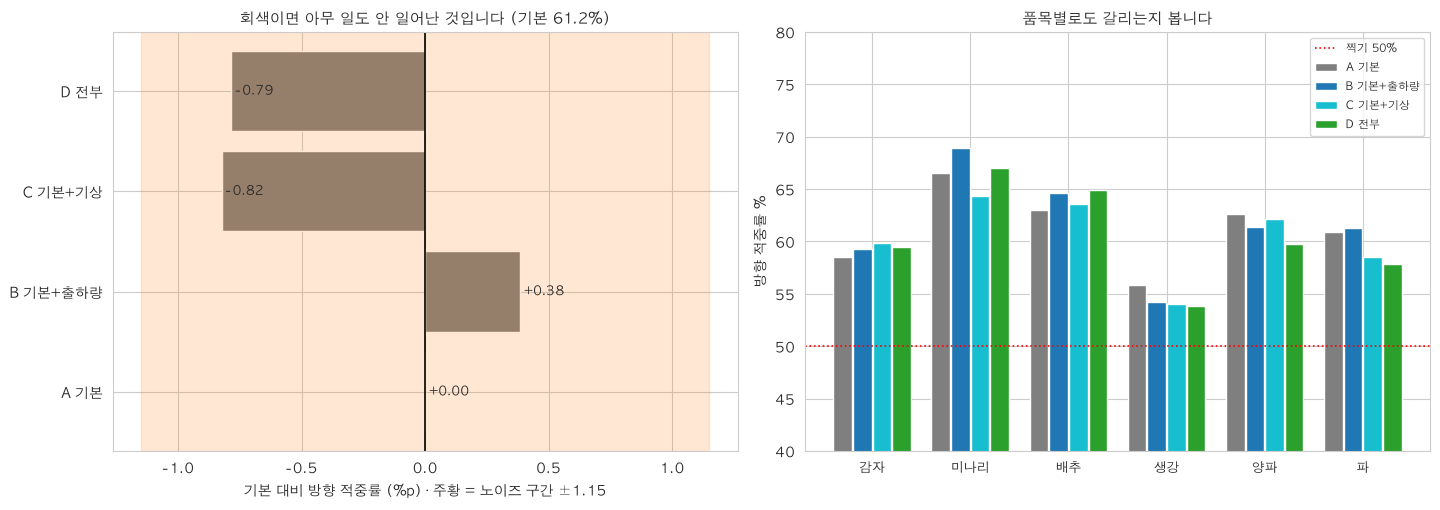

품목별 방향 적중률


,A 기본,B 기본+출하량,C 기본+기상,D 전부,D-A,노이즈 폭,노이즈 넘김
item,,,,,,,
감자,58.5,59.3,59.9,59.4,0.9,2.8,False
미나리,66.6,69.0,64.4,67.0,0.5,1.3,False
배추,63.0,64.6,63.6,64.9,2.0,2.4,False
생강,55.9,54.3,54.0,53.8,-2.1,2.0,True
양파,62.6,61.3,62.2,59.7,-2.9,1.8,True
파,60.9,61.3,58.5,57.8,-3.1,1.8,True


'D-A' 가 '노이즈 폭'보다 커야 그 품목에서 값을 했다고 말할 수 있습니다.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

ax = axes[0]
base = abl.loc["A 기본", "적중률 %"]
diff = abl["기본 대비 %p"]
cols = ["tab:green" if v > FLOOR_MAX else "tab:red" if v < -FLOOR_MAX else "tab:gray"
        for v in diff]
ax.barh(abl.index, diff, color=cols)
ax.axvspan(-FLOOR_MAX, FLOOR_MAX, color="tab:orange", alpha=0.18)
ax.axvline(0, color="black", lw=1.2)
for i, v in enumerate(diff):
    ax.text(v, i, f" {v:+.2f}", va="center", fontsize=9)
ax.set_xlabel(f"기본 대비 방향 적중률 (%p) · 주황 = 노이즈 구간 ±{FLOOR_MAX:.2f}")
ax.set_title(f"회색이면 아무 일도 안 일어난 것입니다 (기본 {base:.1f}%)", fontsize=11)

ax = axes[1]
per = pd.DataFrame({
    n: p.groupby("item").방향맞음.mean() * 100 for n, p in preds.items()})
per = per.loc[items]
x = np.arange(len(per))
for i, (n, c) in enumerate(zip(CONFIGS, ["tab:gray", "tab:blue", "tab:cyan", "tab:green"])):
    ax.bar(x + (i - 1.5) * 0.2, per[n], width=0.19, color=c, label=n)
ax.axhline(50, color="red", ls=":", lw=1.2, label="찍기 50%")
ax.set_xticks(x)
ax.set_xticklabels(per.index, fontsize=9)
ax.set_ylim(40, 80)
ax.set_ylabel("방향 적중률 %")
ax.set_title("품목별로도 갈리는지 봅니다", fontsize=11)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("품목별 방향 적중률")
per["D-A"] = (per["D 전부"] - per["A 기본"]).round(2)
per["노이즈 폭"] = FLOOR_ITEM.round(2)
per["노이즈 넘김"] = per["D-A"].abs() > per["노이즈 폭"]
display(per.round(1))
print("'D-A' 가 '노이즈 폭'보다 커야 그 품목에서 값을 했다고 말할 수 있습니다.")

## 6. 그러면 무엇을 더 모아야 하나: 피처인가 품목인가

출하량·기상이 값을 못 했다면 다음 질문은 이겁니다. **품목을 늘리는 건 어떤가.**

08번에서 6 → 16품목 확대가 도움이 됐습니다. 그게 여기서도 확인되는지 봅니다.
**평가 대상은 똑같은 6품목으로 두고, 학습에 쓰는 품목만 6개와 19개로 바꿉니다.**
평가 대상이 같아야 공정한 비교입니다.

| | 학습 품목 | 평가 품목 |
|---|---|---|
| 지금까지 | 6개 | 6개 |
| 이 절 | **19개** | 6개 |

In [7]:
# 19품목 전체로 학습하고, 같은 6품목만 평가한다
big = raw.sort_values(["item", "price_date"]).reset_index(drop=True)
all_items = sorted(big.item.unique())
big["_logp"] = np.log(big.price_kg_avg)


def gb(c):
    return big.groupby("item")[c]


big["y"] = gb("_logp").shift(-H) - big._logp
big["오름"] = big.y > 0
big["미래가격"] = gb("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    big[f"ret{lag}"] = big._logp - gb("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    big[f"dev{w}"] = big._logp - gb("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    big[f"vol{w}"] = gb("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy2 = big.price_date.dt.dayofyear
big["doy_sin"] = np.sin(2 * np.pi * doy2 / 365.25)
big["doy_cos"] = np.cos(2 * np.pi * doy2 / 365.25)
big["seas_dev"] = big._logp - (big.groupby(["item", "month"])["_logp"]
                               .transform(lambda s: s.shift(1)
                                          .expanding(min_periods=20).mean()))
big["item_code"] = pd.Categorical(big.item, categories=all_items).codes
bigfeat = big.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

cat = [BASE.index(c) for c in ("item_code", "month", "dayofweek")]
out = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = bigfeat[bigfeat.price_date < s - EMBARGO]
    te = bigfeat[(bigfeat.price_date >= s) & (bigfeat.price_date <= e)]
    clf = HistGradientBoostingClassifier(
        categorical_features=cat, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[BASE], tr.오름)
    t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
    t["오를확률"] = clf.predict_proba(te[BASE])[:, 1]
    out.append(t)
r19 = pd.concat(out).reset_index(drop=True)
r19["방향맞음"] = (r19.오를확률 > 0.5) == r19.오름
r19["확신도"] = (r19.오를확률 - 0.5).abs()
r19_6 = r19[r19.item.isin(ITEMS6)].reset_index(drop=True)

비교 = pd.DataFrame([
    {"학습 품목": "6개 (A 기본)", "평가 품목": "6개", **성적(preds["A 기본"])},
    {"학습 품목": "6개 (D 전부)", "평가 품목": "6개", **성적(preds["D 전부"])},
    {"학습 품목": "19개 (기본 피처)", "평가 품목": "6개", **성적(r19_6)},
]).set_index("학습 품목")
비교["기본 대비 %p"] = (비교["적중률 %"] - 비교.loc["6개 (A 기본)", "적중률 %"]).round(2)
display(비교.round(2))
print(f"노이즈 플로어 {FLOOR_MAX:.2f}%p 를 넘는지가 판정 기준입니다.")
print(f"참고: 19품목 전체를 평가하면 {r19.방향맞음.mean()*100:.1f}% 입니다(15번 62.8%).")

,평가 품목,적중률 %,확신한 날 적중률 %,확신한 날 비율 %,더 받은 돈 %,기본 대비 %p
학습 품목,,,,,,
6개 (A 기본),6개,61.24,66.42,35.81,1.92,0.00
6개 (D 전부),6개,60.45,68.88,35.31,1.70,-0.79
19개 (기본 피처),6개,60.61,68.52,28.58,1.81,-0.63


노이즈 플로어 1.15%p 를 넘는지가 판정 기준입니다.
참고: 19품목 전체를 평가하면 62.8% 입니다(15번 62.8%).


## 7. 결론

### 한 줄 요약

**방향을 맞히는 데는 출하량도 기상도 값을 하지 않습니다.** 같은 종류를 더 모을
이유가 없습니다.

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 출하량이 값을 한다 | **+0.38%p** (노이즈 ±1.15%p) | **반증됨** |
| **H2** | 기상이 값을 한다 | **-0.82%p** | **반증됨** |
| **H3** | 06번의 진단이 방향에도 적용된다 | 셋 다 노이즈 이내 | **반증됨** |

| 구성 | 피처수 | 적중률 | 기본 대비 | 노이즈 넘김 |
|---|---|---|---|---|
| A 기본 (가격+달력) | 21 | 61.24% | — | — |
| B 기본+출하량 | 31 | 61.62% | +0.38%p | 아니오 |
| C 기본+기상 | 34 | 60.41% | -0.82%p | 아니오 |
| D 전부 | 44 | 60.45% | -0.79%p | 아니오 |

**피처를 23개 늘려 얻은 게 노이즈 이내입니다.** 방향은 이미 가격 자체(모멘텀·
계절 대비 위치)에 담겨 있고, 출하량·기상이 더 얹을 게 없다는 뜻으로 읽힙니다.

### 품목 셋에서는 오히려 해롭습니다

품목별 노이즈 폭을 따로 쟀습니다. 표본이 6분의 1이라 1.26~2.76%p 로 훨씬 넓습니다.

| 품목 | 전부 넣었을 때 변화 | 그 품목 노이즈 폭 | 판정 |
|---|---|---|---|
| 배추 | +2.0%p | 2.41 | 노이즈 이내 |
| 감자 | +0.9%p | 2.76 | 노이즈 이내 |
| 미나리 | +0.5%p | 1.26 | 노이즈 이내 |
| **생강** | **-2.1%p** | 1.95 | **악화** |
| **양파** | **-2.9%p** | 1.85 | **악화** |
| **파** | **-3.1%p** | 1.84 | **악화** |

**좋아진 품목은 하나도 없고 나빠진 품목이 셋입니다.** 06번에서 기상 충격 지표가
MAPE 를 악화시킨 것(+0.075)과 같은 방향입니다. 척도를 방향으로 바꿔도 결론이
같습니다: **기상은 이 예측 지평에서 해롭습니다.**

### 품목을 늘리는 것도 답이 아닙니다

평가 대상을 같은 6품목으로 고정하고 학습 품목만 바꿨습니다.

| 학습 품목 | 6품목 평가 적중률 | 기본 대비 |
|---|---|---|
| 6개 (기본 피처) | 61.24% | — |
| 6개 (전부 넣기) | 60.45% | -0.79%p |
| **19개 (기본 피처)** | **60.61%** | **-0.63%p** |

**셋 다 노이즈 이내**라, 품목을 3배로 늘려도 이 6품목의 성적은 안 오릅니다.
15번의 19품목 전체 62.8% 가 여기 6품목 61.2% 보다 높은 건 **품목 구성이 다르기
때문**입니다: 엽채류가 원래 잘 맞습니다(08번). 08번의 "엽채류가 가장 잘 맞는다"와
어긋나지 않습니다.

### 왜 이런가 (짐작이지 증명이 아닙니다)

- **가격이 이미 다 담고 있습니다.** 출하량 충격도 기상 충격도 결국 가격에
  나타나는데, 모멘텀·계절 편차 피처가 그걸 이미 읽고 있습니다.
- **시차가 안 맞습니다.** 기상이 작황을 거쳐 가격에 닿기까지 7거래일보다 긴
  시간이 걸립니다. 06번에서도 같은 짐작을 적었습니다.
- **주산지 지점을 평균으로 접으면 국지 피해가 희석됩니다.**

### 남은 실마리: 확신하는 날에서는 출하량이 다를 수 있습니다

전체 적중률과 달리, **확신하는 날만 놓고 보면 출하량 구성이 노이즈 밴드를
벗어납니다.**

| 구성 | 확신한 날 적중률 | 확신한 날 비율 |
|---|---|---|
| 난수 대조 5회 | 66.40 ~ 68.37% | 34.96 ~ 36.48% |
| A 기본 | 66.42% | 35.81% |
| **B 기본+출하량** | **69.56%** | 37.11% |
| D 전부 | 68.88% | 35.31% |

**이건 확정이 아닙니다.** 확신한 날 비율이 35.81% → 37.11% 로 같이 움직여서
비교 대상 표본 자체가 다릅니다. 같은 커버리지로 맞춰 다시 재야 판정이 됩니다.
15번 5절에서 확률 컷과 회귀 크기 컷을 비교할 때 쓴 방법을 그대로 쓰면 됩니다.

**그래도 방향은 바뀌지 않습니다.** 전체 적중률에서 값을 못 했다는 결론은 그대로이고,
이건 "출하량은 애매한 날 걸러낸 뒤에나 쓸모가 있을지 모른다"는 좁은 가능성입니다.

### 한계

- **6품목뿐입니다.** 출하량·기상이 붙은 품목이 그것뿐이라 다른 선택지가 없었습니다.
- **노이즈 플로어가 넓습니다(1.15%p).** 08번의 MAPE 기준 0.03 과 비교하면 훨씬
  큰데, 품목이 6개로 줄고 방향은 이진 판정이라 그렇습니다. **1%p 안팎의 차이는
  이 설정에서 아예 못 잽니다.**
- **파생 피처를 단순하게만 만들었습니다.** 06번이 만든 정교한 충격 지표는 일부러
  안 썼습니다: 거기서 이미 해로웠기 때문입니다.
- **이 지평(7거래일)에서의 결론입니다.** 30일 예측이라면 기상이 값을 할 수 있습니다.
- **생강은 따로 봐야 합니다.** 원천이 갱신되지 않는 문제가 따로 있습니다.

### 다음

1. **신규 13품목 매핑 백필의 우선순위를 내립니다.** 며칠 걸리는 작업인데 값을
   할 근거가 없어졌습니다. 다만 위 실마리가 확정되면 되살아납니다.
2. **출하량 실마리를 같은 커버리지로 다시 재기.** 확신한 날 비율이 달라 지금
   비교는 성립하지 않습니다.
3. **확신하는 날의 쏠림 확인**이 남은 가장 싼 검증입니다.
3. **06번의 새 데이터 목록을 방향 기준으로 다시 평가해야 합니다.** 저장 물량·
   재배면적은 성격이 달라(재고·공급 수준) 이번 결과로 함께 기각할 수 없습니다.